# Silver Layer Processing & Data Quality Report

Pipeline **Bronze → Silver**: pembersihan data, join tabel, rekalkukasi revenue, dan validasi kualitas.  
Output disimpan ke `s3a://silver/integrated_sales` dipartisi per tahun.

**Alur kerja:**
1. ETL Pipeline — Bronze → Silver
2. Verifikasi hasil
3. Data Quality Report — missing values, duplikat, sanity checks
4. Exploratory Data Analysis

In [1]:
import sys

sys.path.append('/home/jovyan/work')

import matplotlib.pyplot as plt
from IPython.display import display
from pyspark.sql import functions as F

from ingestion.spark_client import get_spark_session
from processing.etl_silver import load_bronze_data, save_to_silver_minio

SILVER_PATH = "s3a://silver/integrated_sales"

spark = get_spark_session(app_name="Silver-Layer-Processing")
print("Spark Session ready.")

Spark Session ready.


## 1. ETL Pipeline — Bronze → Silver

Preprocessing dilakukan langsung di notebook ini agar setiap langkah transformasi dapat diinspeksi dan divalidasi secara interaktif.

`etl_silver.py` hanya bertanggung jawab untuk **load** dari Bronze dan **save** ke Silver MinIO.

| Langkah | Deskripsi |
|---------|-----------|
| **1.1** Load Bronze | Baca tabel `sales`, `customers`, `items` dari MinIO |
| **1.2** Deduplikasi | Hapus baris duplikat & baris tanpa `customer_id` |
| **1.3** Join Tabel | `sales` ← join → `customers` ← join → `items` |
| **1.4** Rekalkukasi Revenue | `revenue = quantity × unit_price` (nilai asli = 0) |
| **1.5** Tambah Kolom Partisi | Ekstrak kolom `year` dari `invoice_date` |
| **1.6** Simpan ke Silver | Tulis ke `s3a://silver/integrated_sales` partisi per tahun |

In [2]:
# 1.1 — Load Bronze
sales, customers, items = load_bronze_data(spark)

print(f"sales     : {sales.count():,} baris,     kolom: {len(sales.columns)}")
print(f"customers : {customers.count():,} baris, kolom: {len(customers.columns)}")
print(f"items     : {items.count():,} baris,     kolom: {len(items.columns)}")

[Silver] Membaca data Bronze...
sales     : 998,224 baris,     kolom: 7
customers : 500,000 baris, kolom: 9
items     : 98 baris,     kolom: 6


In [3]:
from pyspark.sql import functions as F

# 1.2 — Deduplikasi & hapus baris tanpa customer_id
before = sales.count()
cleaned_sales = sales.dropDuplicates().dropna(subset=["customer_id"])
after = cleaned_sales.count()

print(f"Baris sebelum cleaning : {before:,}")
print(f"Baris setelah cleaning : {after:,}")
print(f"Baris dihapus          : {before - after:,}  ({(before - after) / before * 100:.2f}%)")

Baris sebelum cleaning : 998,224
Baris setelah cleaning : 990,923
Baris dihapus          : 7,301  (0.73%)


In [4]:
# 1.3 — Join: sales + customers + items (left join untuk mempertahankan semua transaksi)
integrated_df = (
    cleaned_sales
    .join(customers, "customer_id", "left")
    .join(items, "product_id", "left")
)

print(f"Baris setelah join : {integrated_df.count():,}")
print(f"Total kolom        : {len(integrated_df.columns)}")
print(f"Kolom              : {integrated_df.columns}")

Baris setelah join : 990,923
Total kolom        : 20
Kolom              : ['product_id', 'customer_id', 'invoice_id', 'invoice_date', 'quantity', 'revenue', 'store_id', 'created_at', 'first_name', 'last_name', 'email', 'phone', 'email_opt_in', 'sms_opt_in', 'call_opt_in', 'product_name', 'brand', 'category', 'gramm_g', 'unit_price']


In [5]:
# 1.4 — Rekalkukasi revenue: quantity × unit_price
# Revenue di source sales bernilai 0, sehingga harus dihitung ulang
silver_df = integrated_df.withColumn(
    "revenue",
    F.col("quantity").cast("double") * F.col("unit_price").cast("double")
)

# Validasi: pastikan tidak ada revenue = 0 atau negatif setelah rekalkukasi
zero_rev = silver_df.filter(F.col("revenue") <= 0).count()
print(f"Revenue nol/negatif setelah rekalkukasi : {zero_rev:,}")

silver_df.select("quantity", "unit_price", "revenue").show(5)

Revenue nol/negatif setelah rekalkukasi : 0
+--------+----------+-------+
|quantity|unit_price|revenue|
+--------+----------+-------+
|       1|      22.5|   22.5|
|       1|      19.5|   19.5|
|       1|      21.0|   21.0|
|       1|      53.5|   53.5|
|       1|      58.5|   58.5|
+--------+----------+-------+
only showing top 5 rows



In [6]:
# 1.5 — Tambah kolom partisi 'year' dari invoice_date
silver_df = silver_df.withColumn("year", F.year("invoice_date"))

print("Distribusi baris per tahun:")
silver_df.groupBy("year").count().orderBy("year").show()

# 1.6 — Simpan ke Silver MinIO
save_to_silver_minio(silver_df, spark)

Distribusi baris per tahun:
+----+-----+
|year|count|
+----+-----+
|2015|87447|
|2016|90483|
|2017|90461|
|2018|90039|
|2019|90242|
|2020|90186|
|2021|90792|
|2022|90517|
|2023|90507|
|2024|90021|
|2025|90228|
+----+-----+

[Silver] Menyimpan ke MinIO dengan Partisi Tahun...
🎉 Layer Silver Berhasil Disimpan di: s3a://silver/integrated_sales


## 2. Verification

Baca kembali hasil dari MinIO untuk memastikan data tersimpan dengan benar.

In [7]:
df_silver = spark.read.parquet(SILVER_PATH).cache()
total_rows = df_silver.count()

print(f"Total rows in Silver Layer: {total_rows:,}")
df_silver.printSchema()
df_silver.groupBy("year").count().orderBy("year").show()
df_silver.show(5)

Total rows in Silver Layer: 990,923
root
 |-- product_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- invoice_id: string (nullable = true)
 |-- invoice_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- revenue: double (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- created_at: date (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- email_opt_in: integer (nullable = true)
 |-- sms_opt_in: integer (nullable = true)
 |-- call_opt_in: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- category: string (nullable = true)
 |-- gramm_g: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- year: integer (nullable = true)

+----+-----+
|year|count|
+----+-----+
|2015|87447|
|2016|90483|
|2017|90461|
|2018|90039|
|2019|

## 3. Data Quality Report

In [8]:
missing_exprs = [
    F.sum(
        F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), 1).otherwise(0)
    ).alias(c)
    for c in df_silver.columns
]

missing_pd = (
    df_silver.select(missing_exprs)
    .toPandas().T
    .reset_index()
    .rename(columns={"index": "column_name", 0: "missing_count"})
)
missing_pd["missing_pct"] = (missing_pd["missing_count"] / total_rows * 100).round(2)
missing_pd = missing_pd.sort_values(["missing_count", "column_name"], ascending=[False, True])

print("=== Missing Values per Column ===")
display(missing_pd)

=== Missing Values per Column ===


,column_name,missing_count,missing_pct
9,last_name,396812,40.04
10,email,298686,30.14
11,phone,198941,20.08
8,first_name,98536,9.94
18,gramm_g,75823,7.65
16,brand,0,0.00
14,call_opt_in,0,0.00
17,category,0,0.00
7,created_at,0,0.00
1,customer_id,0,0.00


In [9]:
dup_full = total_rows - df_silver.dropDuplicates().count()
dup_txn  = total_rows - df_silver.dropDuplicates(["invoice_id", "product_id", "customer_id", "store_id"]).count()

print(f"Duplicate full rows:        {dup_full:,}")
print(f"Duplicate transaction rows: {dup_txn:,}")

Duplicate full rows:        0
Duplicate transaction rows: 0


In [10]:
quality_checks_pd = (
    df_silver.agg(
        F.sum(F.when(F.col("customer_id").isNull(), 1).otherwise(0)).alias("null_customer_id"),
        F.sum(F.when(F.col("product_id").isNull(), 1).otherwise(0)).alias("null_product_id"),
        F.sum(F.when(F.col("invoice_id").isNull(), 1).otherwise(0)).alias("null_invoice_id"),
        F.sum(F.when(F.col("invoice_date").isNull(), 1).otherwise(0)).alias("null_invoice_date"),
        F.sum(F.when(F.col("quantity") <= 0, 1).otherwise(0)).alias("non_positive_quantity"),
        F.sum(F.when(F.col("unit_price") <= 0, 1).otherwise(0)).alias("non_positive_unit_price"),
        F.sum(F.when(F.col("revenue") < 0, 1).otherwise(0)).alias("negative_revenue"),
        F.sum(F.when(F.col("revenue") == 0, 1).otherwise(0)).alias("zero_revenue_rows"),
    )
    .toPandas().T
    .reset_index()
    .rename(columns={"index": "check_name", 0: "row_count"})
)
quality_checks_pd["row_pct"] = (quality_checks_pd["row_count"] / total_rows * 100).round(2)

print("=== Sanity Checks ===")
display(quality_checks_pd.sort_values(["row_count", "check_name"], ascending=[False, True]))

print("\n=== Descriptive Statistics — Numeric Columns ===")
display(df_silver.select("quantity", "revenue", "unit_price", "gramm_g").summary().toPandas())

=== Sanity Checks ===


,check_name,row_count,row_pct
6,negative_revenue,0,0.0
4,non_positive_quantity,0,0.0
5,non_positive_unit_price,0,0.0
0,null_customer_id,0,0.0
3,null_invoice_date,0,0.0
2,null_invoice_id,0,0.0
1,null_product_id,0,0.0
7,zero_revenue_rows,0,0.0



=== Descriptive Statistics — Numeric Columns ===


,summary,quantity,revenue,unit_price,gramm_g
0,count,990923,990923,990923,915100
1,mean,1.0,39.877505618499114,39.877505618499114,47.95558955305431
2,stddev,5.55108159536615E-17,69.35344856814966,69.35344856814966,62.232924134669105
3,min,1,7.0,7.0,10
4,25%,1,13.0,13.0,20
5,50%,1,19.5,19.5,30
6,75%,1,52.0,52.0,50
7,max,1,569.5,569.5,500


## 4. Exploratory Data Analysis

In [11]:
# Enrich df_silver sekali untuk semua analisis berikut
analyst_df = (
    df_silver
    .withColumn("year_month", F.date_format("invoice_date", "yyyy-MM"))
    .withColumn("estimated_gross_sales", F.col("quantity") * F.col("unit_price"))
)

In [12]:
print("=== Silver Layer KPI Summary ===")
display(
    analyst_df.agg(
        F.countDistinct("invoice_id").alias("total_invoices"),
        F.count("*").alias("total_rows"),
        F.sum("quantity").alias("total_quantity"),
        F.round(F.sum("estimated_gross_sales"), 2).alias("estimated_gross_sales"),
        F.countDistinct("customer_id").alias("active_customers"),
        F.countDistinct("product_id").alias("active_products"),
        F.countDistinct("store_id").alias("active_stores"),
    ).toPandas()
)

=== Silver Layer KPI Summary ===


,total_invoices,total_rows,total_quantity,estimated_gross_sales,active_customers,active_products,active_stores
0,961145,990923,990923,39515537.5,294031,98,9


In [13]:
print("=== Monthly Trend ===")
display(
    analyst_df
    .groupBy("year_month")
    .agg(
        F.countDistinct("invoice_id").alias("total_invoices"),
        F.sum("quantity").alias("total_quantity"),
        F.round(F.sum("estimated_gross_sales"), 2).alias("estimated_gross_sales"),
    )
    .orderBy("year_month")
    .toPandas()
)

=== Monthly Trend ===


,year_month,total_invoices,total_quantity,estimated_gross_sales
0,2015-01,1931,4780,606385.5
1,2015-02,4303,7541,788086.0
2,2015-03,5436,7401,694717.5
3,2015-04,6047,7589,646584.0
4,2015-05,6329,7546,571114.0
...,...,...,...,...
127,2025-08,7476,7523,247316.0
128,2025-09,7358,7405,241198.5
129,2025-10,7404,7459,242533.5
130,2025-11,7416,7460,236973.0


In [14]:
print("=== Top 10 Brands by Estimated Gross Sales ===")
display(
    analyst_df
    .groupBy("brand")
    .agg(
        F.countDistinct("invoice_id").alias("total_invoices"),
        F.sum("quantity").alias("total_quantity"),
        F.round(F.sum("estimated_gross_sales"), 2).alias("estimated_gross_sales"),
    )
    .orderBy(F.desc("estimated_gross_sales"))
    .limit(10)
    .toPandas()
)

=== Top 10 Brands by Estimated Gross Sales ===


,brand,total_invoices,total_quantity,estimated_gross_sales
0,BreezeLine,219406,221447,14583658.0
1,FreshNest,207098,208791,9655788.5
2,AromaWave,194104,195079,6594377.5
3,Good Smell,170398,171116,4749537.5
4,Citrus & Co,181414,182229,3197581.0
5,AromaDrive,12260,12261,734595.0


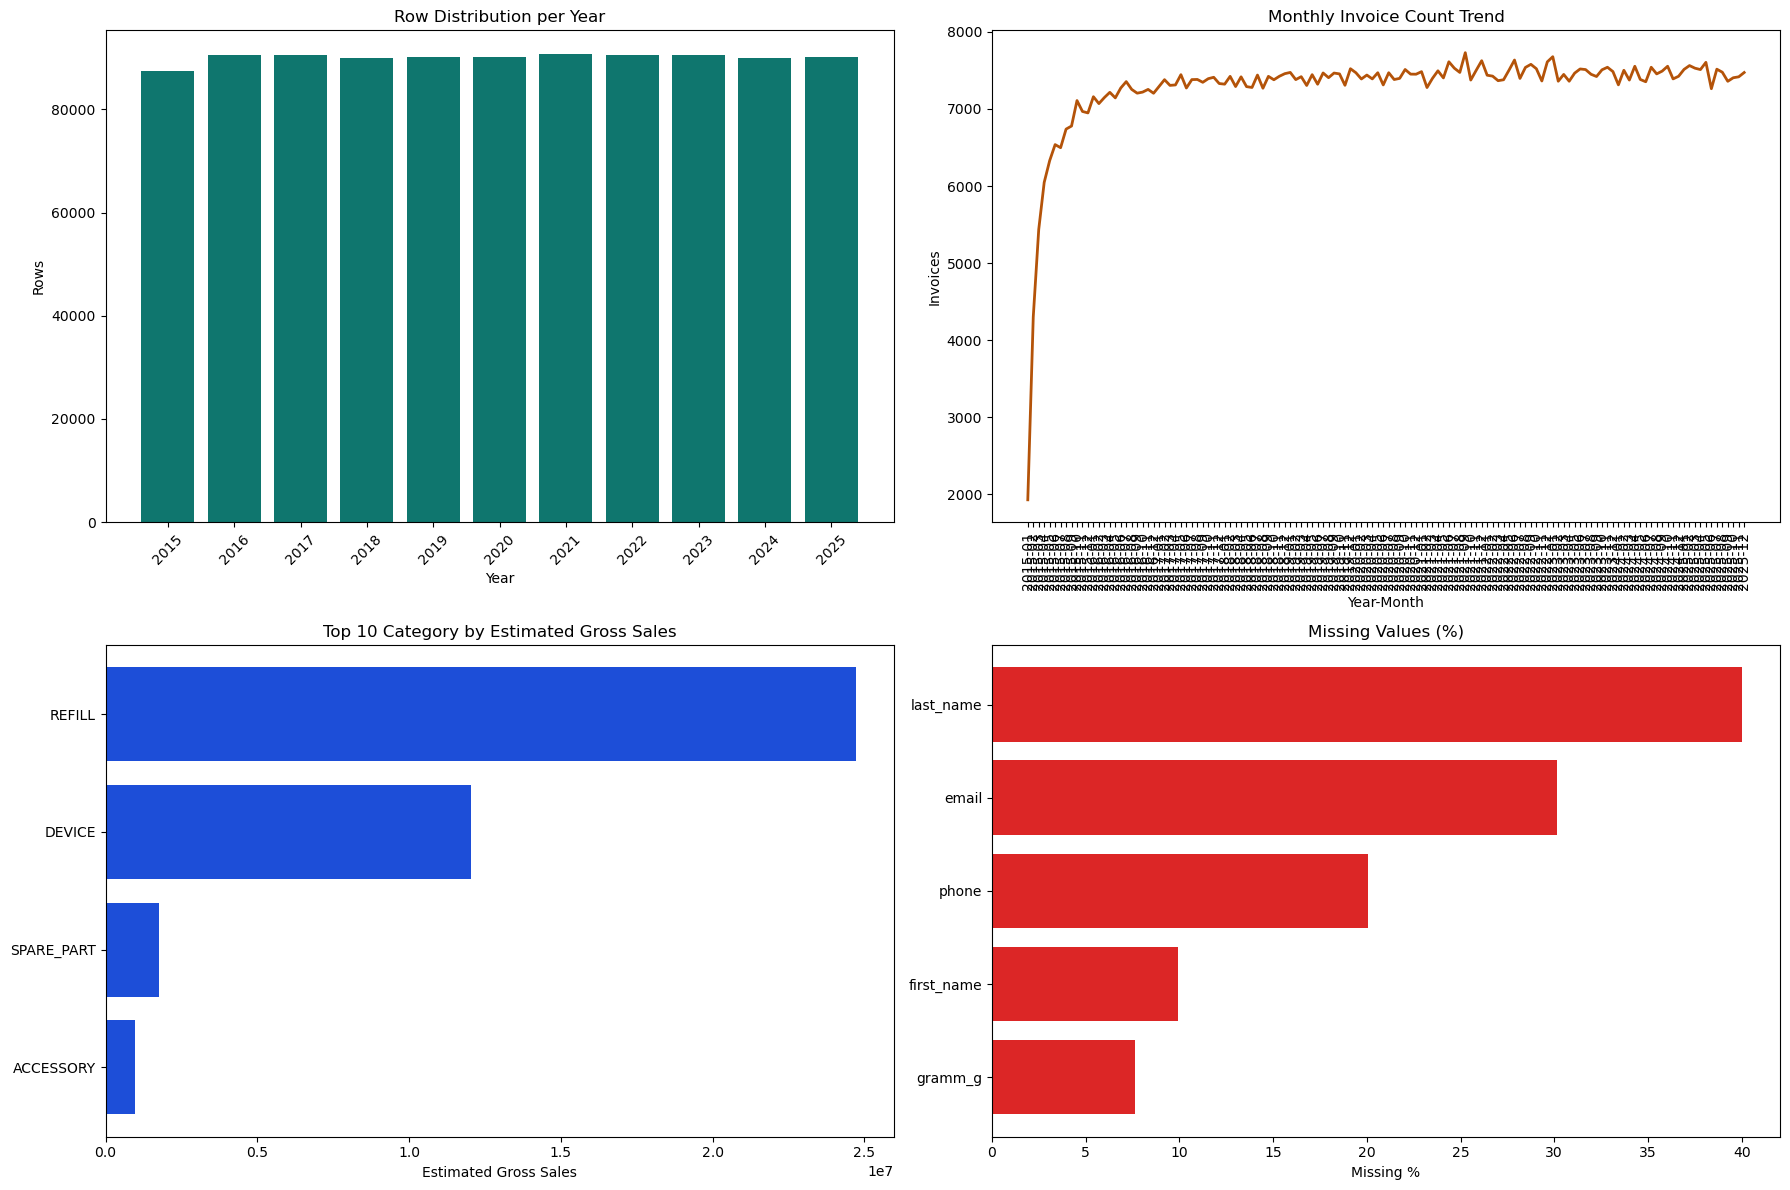

In [15]:
yearly_pd       = analyst_df.groupBy("year").count().orderBy("year").toPandas()
monthly_pd      = (
    analyst_df
    .groupBy("year_month")
    .agg(F.countDistinct("invoice_id").alias("total_invoices"))
    .orderBy("year_month")
    .toPandas()
)
top_category_pd = (
    analyst_df
    .groupBy("category")
    .agg(F.round(F.sum("estimated_gross_sales"), 2).alias("estimated_gross_sales"))
    .orderBy(F.desc("estimated_gross_sales"))
    .limit(10)
    .toPandas()
)
top_missing_pd = missing_pd[missing_pd["missing_count"] > 0].head(10)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(yearly_pd["year"].astype(str), yearly_pd["count"], color="#0f766e")
axes[0, 0].set_title("Row Distribution per Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Rows")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].plot(monthly_pd["year_month"], monthly_pd["total_invoices"], color="#b45309", linewidth=2)
axes[0, 1].set_title("Monthly Invoice Count Trend")
axes[0, 1].set_xlabel("Year-Month")
axes[0, 1].set_ylabel("Invoices")
axes[0, 1].tick_params(axis="x", rotation=90)

axes[1, 0].barh(top_category_pd["category"], top_category_pd["estimated_gross_sales"], color="#1d4ed8")
axes[1, 0].set_title("Top 10 Category by Estimated Gross Sales")
axes[1, 0].set_xlabel("Estimated Gross Sales")
axes[1, 0].invert_yaxis()

if not top_missing_pd.empty:
    axes[1, 1].barh(top_missing_pd["column_name"], top_missing_pd["missing_pct"], color="#dc2626")
    axes[1, 1].set_title("Missing Values (%)")
    axes[1, 1].set_xlabel("Missing %")
    axes[1, 1].invert_yaxis()
else:
    axes[1, 1].text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=12)
    axes[1, 1].set_title("Missing Values (%)")
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

In [16]:
spark.stop()
print("Spark session closed.")

Spark session closed.
